<a href="https://colab.research.google.com/github/mushrifahamed/DL-Assignment1/blob/custom_cnn/Brain_Tumor_CNN_Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1: Set Up Your Notebook Environment**

1. **Import libraries**
   You’ll need standard libraries for deep learning, image handling, and plotting:

In [ ]:
# TensorFlow/Keras for building the CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For numerical operations and plotting
import numpy as np
import matplotlib.pyplot as plt
import os

## **Step 2: Prepare the Dataset**

Since your dataset is from Kaggle:

1. **Upload Kaggle API token (`kaggle.json`) to Colab**.
2. **Install Kaggle package** if not installed:

In [ ]:
!pip install kaggle

3. **Set up Kaggle credentials in Colab**:

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

4. **Download the dataset**:

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 98% 145M/149M [00:00<00:00, 1.52GB/s]
100% 149M/149M [00:00<00:00, 1.50GB/s]


5. **Check folder structure** (to understand class subfolders):

In [ ]:
!ls /content/brain_tumor_dataset

Testing  Training


## **Step 3: Image Preprocessing**
We handle the preprocessing of the image data. This involves resizing and normalizing the images using ImageDataGenerator and setting up data generators for training, validation, and testing.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # Split validation from training
    rotation_range=10, # Reduced from 20
    width_shift_range=0.05, # Reduced from 0.1
    height_shift_range=0.05, # Reduced from 0.1
    zoom_range=0.05, # Reduced from 0.1
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255) # No augmentation for testing

train_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Training', # Point to Training folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training' # Use the training subset
)

validation_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Training', # Point to Training folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation' # Use the validation subset
)

test_generator = test_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Testing', # Point to Testing folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


##**Step 4: Build the CNN Model**
Here, we define the architecture of the Convolutional Neural Network (CNN) model using TensorFlow/Keras. This includes adding convolutional layers, pooling layers, flatten layer, and dense layers. The model is then compiled with an optimizer and loss function.

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')   # 4 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,476 (12.67 MB)

 Trainable params: 3,321,476 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

##**Step 5: Handle Class Imbalance and Train the Model**
We address the class imbalance in the dataset by computing class weights. Then, we train the CNN model using the training data, with validation data for monitoring and early stopping to prevent overfitting.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class indices from train generator
classes = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


In [ ]:
# Step 5: Train the Model
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 266ms/step - accuracy: 0.5074 - loss: 1.0698 - val_accuracy: 0.6196 - val_loss: 0.8959
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 225ms/step - accuracy: 0.7834 - loss: 0.5710 - val_accuracy: 0.7090 - val_loss: 0.7552
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.8144 - loss: 0.4849 - val_accuracy: 0.7485 - val_loss: 0.6528
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.8586 - loss: 0.3980 - val_accuracy: 0.7993 - val_loss: 0.5532
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 32s 226ms/step - accuracy: 0.8621 - loss: 0.3695 - val_accuracy: 0.7677 - val_loss: 0.6552
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 216ms/step - accuracy: 0.8924 - loss: 0.3115 - val_accuracy: 0.8177 - val_loss: 0.5467
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 33s 229ms/step - accuracy: 0.9005 - loss: 0.2959 - val_accuracy: 0.7993 - val_loss: 0.5421
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 31s 219ms/step - accuracy: 0.9069 - loss: 0

##**Step 6: Visualize Training History**
Here, we visualize the training history of the model by plotting the training and validation accuracy and loss over epochs. We also print the final and best performance metrics.

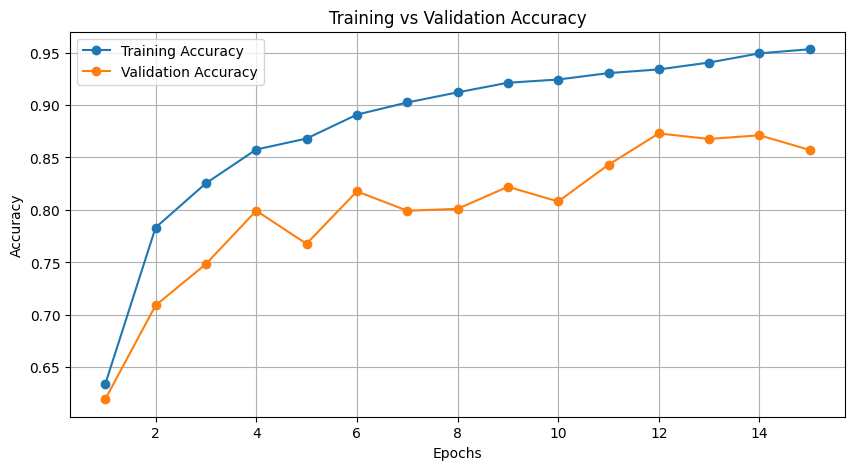

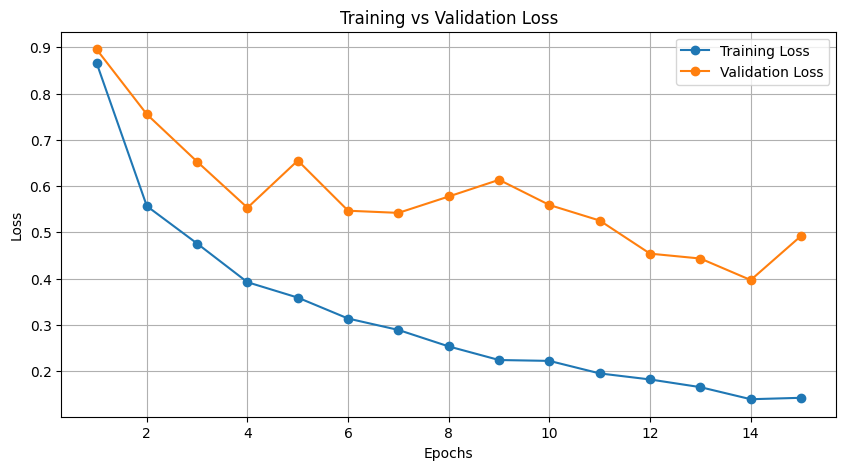

Final Training Accuracy: 95.32%
Final Validation Accuracy: 85.71%
Final Training Loss: 0.1423
Final Validation Loss: 0.4923

Best Validation Accuracy: 87.29% at Epoch 12


In [ ]:
import matplotlib.pyplot as plt

# Get history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Text Outputs for Easy Reading
print("Final Training Accuracy: {:.2f}%".format(acc[-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(val_acc[-1] * 100))
print("Final Training Loss: {:.4f}".format(loss[-1]))
print("Final Validation Loss: {:.4f}".format(val_loss[-1]))

# Compare best epoch
best_epoch = val_acc.index(max(val_acc)) + 1
print("\nBest Validation Accuracy: {:.2f}% at Epoch {}".format(max(val_acc) * 100, best_epoch))


In [ ]:
# Text-only visualization of accuracy & loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

print("\nEpoch | Train Acc | Val Acc | Train Loss | Val Loss")
print("-"*55)

for i in range(len(acc)):
    print("{:5d} | {:9.4f} | {:7.4f} | {:11.4f} | {:8.4f}".format(
        i+1, acc[i], val_acc[i], loss[i], val_loss[i]
    ))

# Show final & best
best_epoch = val_acc.index(max(val_acc)) + 1
print("\nFinal Training Accuracy: {:.2f}%".format(acc[-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(val_acc[-1] * 100))
print("Final Training Loss: {:.4f}".format(loss[-1]))
print("Final Validation Loss: {:.4f}".format(val_loss[-1]))
print("Best Validation Accuracy: {:.2f}% at Epoch {}".format(max(val_acc) * 100, best_epoch))



Epoch | Train Acc | Val Acc | Train Loss | Val Loss
-------------------------------------------------------
    1 |    0.6340 |  0.6196 |      0.8668 |   0.8959
    2 |    0.7832 |  0.7090 |      0.5567 |   0.7552
    3 |    0.8254 |  0.7485 |      0.4758 |   0.6528
    4 |    0.8576 |  0.7993 |      0.3922 |   0.5532
    5 |    0.8681 |  0.7677 |      0.3589 |   0.6552
    6 |    0.8908 |  0.8177 |      0.3136 |   0.5467
    7 |    0.9024 |  0.7993 |      0.2890 |   0.5421
    8 |    0.9121 |  0.8011 |      0.2533 |   0.5775
    9 |    0.9212 |  0.8221 |      0.2239 |   0.6136
   10 |    0.9243 |  0.8081 |      0.2221 |   0.5591
   11 |    0.9304 |  0.8431 |      0.1950 |   0.5255
   12 |    0.9339 |  0.8729 |      0.1819 |   0.4539
   13 |    0.9405 |  0.8677 |      0.1653 |   0.4434
   14 |    0.9492 |  0.8712 |      0.1392 |   0.3969
   15 |    0.9532 |  0.8571 |      0.1423 |   0.4923

Final Training Accuracy: 95.32%
Final Validation Accuracy: 85.71%
Final Training Loss: 0.1423
F

##**Step 7: Evaluate the Model**

Finally, we evaluate the trained model's performance on the test set. This involves calculating and printing the test accuracy and loss, generating a classification report, and displaying a confusion matrix to assess the model's performance for each class.

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.8607 - loss: 0.3795

Test Accuracy: 91.30%
Test Loss: 0.2576
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.83      0.91       300
  meningioma       0.83      0.82      0.82       306
     notumor       0.90      0.99      0.94       405
   pituitary       0.94      0.99      0.96       300

    accuracy                           0.91      1311
   macro avg       0.92      0.91      0.91      1311
weighted avg       0.92      0.91      0.91      1311



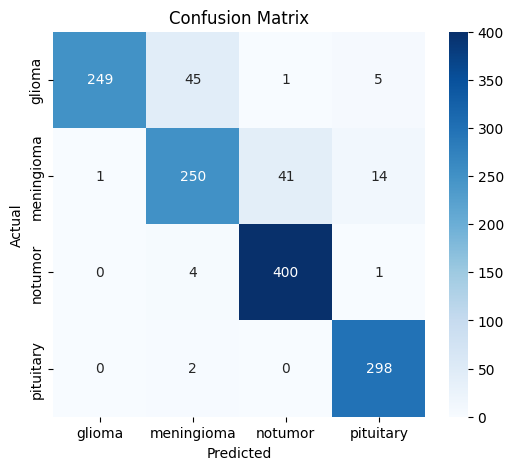

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Evaluate accuracy on test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. Get predictions
# Since test_generator shuffles=False, the order is maintained
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Classification report
print("\nClassification Report:")
# Get class names from the generator
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Step 8: Save Model Results

In this step, we save the trained model so that it can be loaded and used later without retraining.

In [ ]:
# Save the model
model.save('brain_tumor_cnn_model.keras')
print("Model saved successfully!")

Model saved successfully!


## **Step 9: Predict on a Single Image**

In this step, we will load the saved model and use it to predict the class of a single image from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


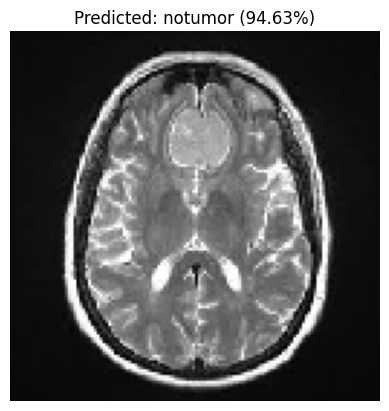

The model predicts this image belongs to the 'notumor' class with 94.63% confidence.


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load the saved model
loaded_model = load_model('brain_tumor_cnn_model.keras')

# Get class names from the test generator
class_names = list(test_generator.class_indices.keys())

# Choose an image to test
test_dir = '/content/brain_tumor_dataset/Testing'
# Pick image
img_path = os.path.join(test_dir, 'meningioma', os.listdir(os.path.join(test_dir, 'meningioma'))[6])

# Load and preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0

# Make a prediction
predictions = loaded_model.predict(img_array)
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(predictions) * 100

# Display the image and prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"The model predicts this image belongs to the '{predicted_class_name}' class with {confidence:.2f}% confidence.")